# 03 — Qualitative Forecast Results

This notebook presents representative qualitative outputs from the held-out baseline.

Focus:
- representative forecast panel
- failure / limitation case
- GT-vs-prediction GIFs
- interpretation of smoothing and structural drift

In [1]:
from pathlib import Path
from IPython.display import Image, display

PRED_DIR = Path("../outputs/predictions/baseline_desktop")
REPORT_FIGURES_DIR = Path("../reports/figures")

representative_compact = PRED_DIR / "compact_test_0.png"
representative_example = PRED_DIR / "example_test_0.png"
representative_gif = PRED_DIR / "pred_vs_gt_test_0.gif"

failure_compact = PRED_DIR / "compact_test_25.png"
failure_example = PRED_DIR / "example_test_25.png"
failure_gif = PRED_DIR / "pred_vs_gt_test_25.gif"

for p in [
    representative_compact,
    representative_example,
    representative_gif,
    failure_compact,
    failure_example,
    failure_gif,
]:
    print(p, "exists:", p.exists())

../outputs/predictions/baseline_desktop/compact_test_0.png exists: True
../outputs/predictions/baseline_desktop/example_test_0.png exists: True
../outputs/predictions/baseline_desktop/pred_vs_gt_test_0.gif exists: True
../outputs/predictions/baseline_desktop/compact_test_25.png exists: True
../outputs/predictions/baseline_desktop/example_test_25.png exists: True
../outputs/predictions/baseline_desktop/pred_vs_gt_test_25.gif exists: True


## Representative case

This case is a good README-style example because the model clearly captures the broad storm location and motion pattern, while still exposing the baseline limitation: progressive smoothing at later horizons.

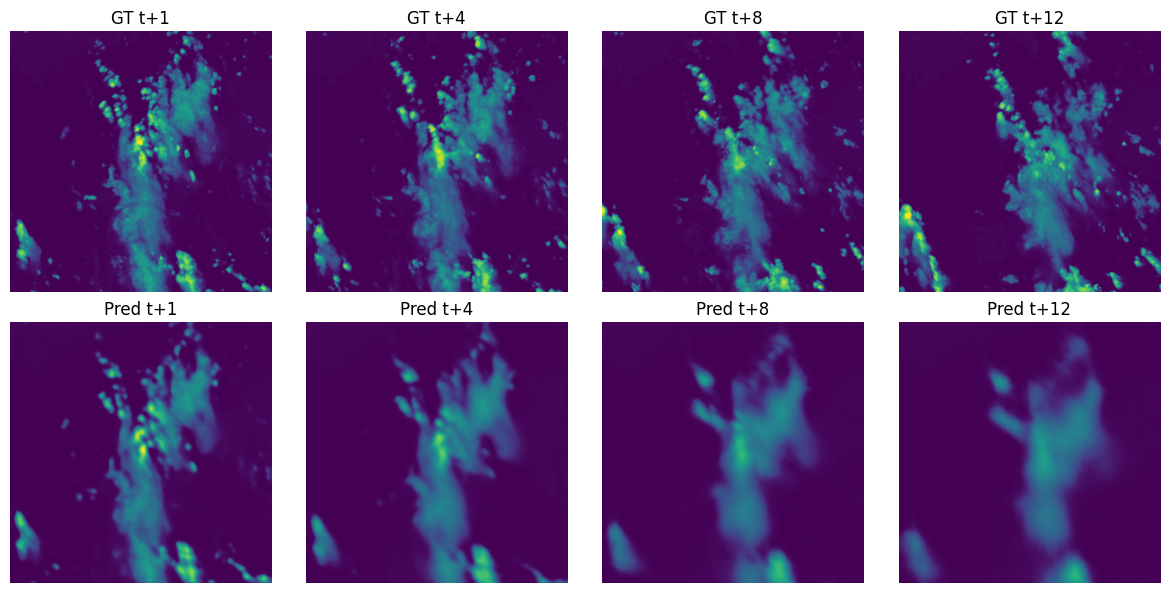

In [2]:
display(Image(filename=str(representative_compact)))

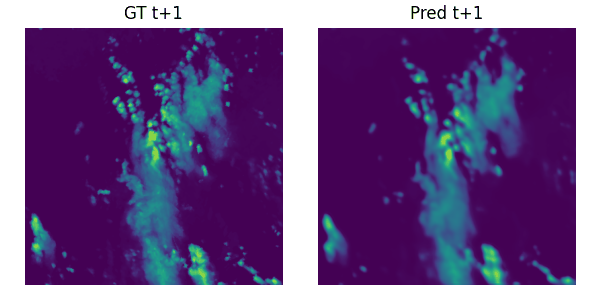

In [3]:
display(Image(filename=str(representative_gif)))

## Interpretation of the representative case

The baseline does a few things reasonably well:

- preserves the approximate storm footprint
- tracks large-scale motion direction
- keeps near-horizon structure broadly plausible

But the failure mode is already visible:

- fine-scale convective structure is softened
- sharp high-intensity pockets are muted
- later-horizon frames become increasingly smooth and low-detail

This is consistent with the quantitative gap between standard MAE and weighted MAE.

## Failure / limitation case

This case is more useful for discussing what the baseline misses.

Here, the model collapses a more fragmented target structure into a smoother and simpler shape, especially deeper into the horizon.

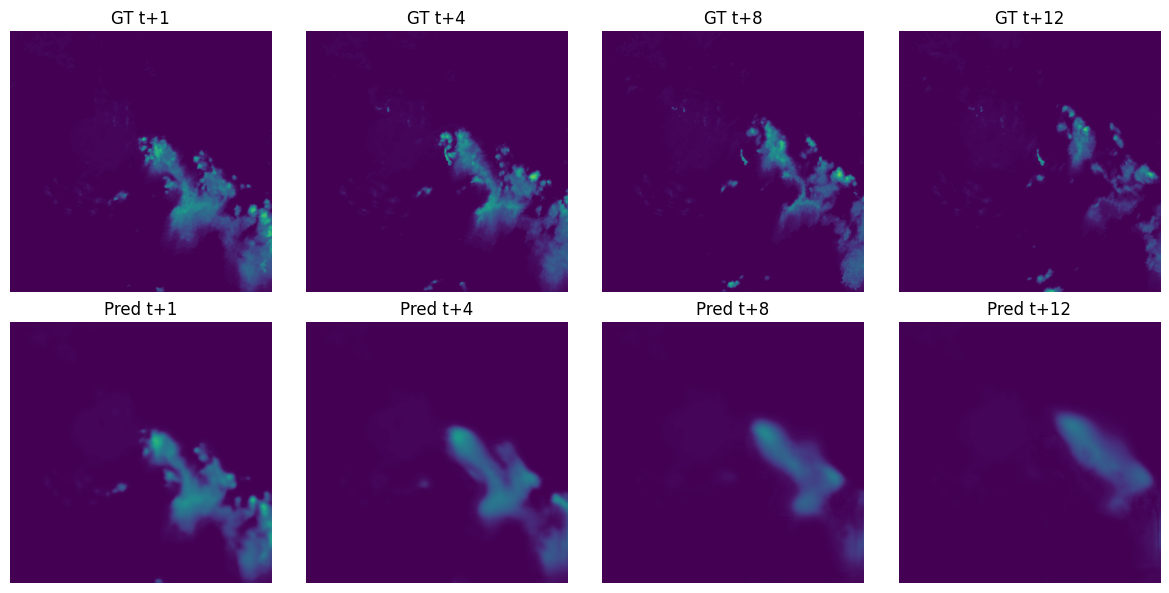

In [4]:
display(Image(filename=str(failure_compact)))

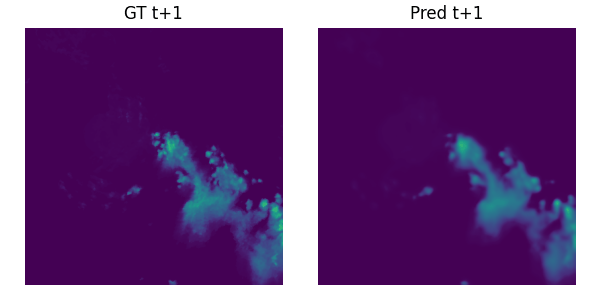

In [5]:
display(Image(filename=str(failure_gif)))

## Interpretation of the limitation case

This is the clearest qualitative weakness of the baseline:

- fragmented storm structure is simplified too aggressively
- high-intensity local peaks are blurred
- later-horizon predictions look increasingly like a smooth mean field rather than a sharp convective pattern

This is exactly why MAE alone is not the whole story.

Pixelwise losses reward conservative averages when the future is uncertain, which keeps overall MAE reasonable but tends to reduce structural sharpness.

## How this links back to the metrics

The qualitative outputs make the metric story more concrete:

- **MAE** says the baseline is competitive overall
- **weighted MAE** says the model struggles more once stronger storm regions matter more
- **SSIM** gives a useful structural complement, but does not fully hide the visual smoothing seen in later frames

Together, the figures and metrics support a very specific next step:
keep the current model as the baseline, then test whether intensity-aware or structure-aware training objectives improve later-horizon behaviour without breaking the original benchmark.